## IMPORTS Y RUTAS

In [1]:
import pandas as pd
import numpy as np
from pathlib import Path

BASE_DIR = Path("..")
PROCESSED_DIR = BASE_DIR / "data" / "processed"

input_path = PROCESSED_DIR / "housing_dataset_clean.csv"
output_path = PROCESSED_DIR / "housing_dataset_europe_features.csv"

df = pd.read_csv(input_path)
df["date"] = pd.to_datetime(df["date"])

df = df.sort_values(["country", "date"]).reset_index(drop=True)

df.head()

,date,country,hpi,hicp,inflation_yoy,unemployment_rate,housing_overburden_rate,ecb_main_refinancing_rate
0,2014-01-01,Alemania,93.8,99.066667,0.951087,4.8,15.9,0.25
1,2014-04-01,Alemania,95.7,99.200000,0.915565,4.7,15.9,0.25
2,2014-07-01,Alemania,96.2,99.666667,0.775194,4.6,15.9,0.15
3,2014-10-01,Alemania,96.2,99.333333,0.438153,4.6,15.9,0.05
4,2015-01-01,Alemania,97.8,98.933333,-0.134590,4.5,15.6,0.05


## COMPROBAR DATASET DE ENTRADA

In [2]:
print(df.shape)
print(df.columns.tolist())
print(df["country"].unique())

df.groupby("country")["date"].agg(["min", "max", "count"])

(1248, 8)
['date', 'country', 'hpi', 'hicp', 'inflation_yoy', 'unemployment_rate', 'housing_overburden_rate', 'ecb_main_refinancing_rate']
['Alemania' 'Austria' 'Bulgaria' 'Bélgica' 'Chequia' 'Chipre' 'Croacia'
 'Dinamarca' 'Eslovaquia' 'Eslovenia' 'España' 'Estonia' 'Finlandia'
 'Francia' 'Hungría' 'Irlanda' 'Italia' 'Letonia' 'Lituania' 'Luxemburgo'
 'Malta' 'Países Bajos' 'Polonia' 'Portugal' 'Rumanía' 'Suecia']


,min,max,count
country,,,
Alemania,2014-01-01,2025-10-01,48
Austria,2014-01-01,2025-10-01,48
Bulgaria,2014-01-01,2025-10-01,48
Bélgica,2014-01-01,2025-10-01,48
Chequia,2014-01-01,2025-10-01,48
Chipre,2014-01-01,2025-10-01,48
Croacia,2014-01-01,2025-10-01,48
Dinamarca,2014-01-01,2025-10-01,48
Eslovaquia,2014-01-01,2025-10-01,48


## ORDENAR Y CREAR VARIABLES TEMPORALES

In [3]:
df["year"] = df["date"].dt.year
df["quarter"] = df["date"].dt.quarter

df["hpi_target_1q"] = (
    df
    .groupby("country")["hpi"]
    .shift(-1)
)

df[["date", "country", "hpi", "hpi_target_1q"]].head(10)

,date,country,hpi,hpi_target_1q
0,2014-01-01,Alemania,93.8,95.7
1,2014-04-01,Alemania,95.7,96.2
2,2014-07-01,Alemania,96.2,96.2
3,2014-10-01,Alemania,96.2,97.8
4,2015-01-01,Alemania,97.8,99.9
5,2015-04-01,Alemania,99.9,100.4
6,2015-07-01,Alemania,100.4,101.8
7,2015-10-01,Alemania,101.8,103.9
8,2016-01-01,Alemania,103.9,106.9
9,2016-04-01,Alemania,106.9,108.8


## CREAR LAGS DEL HPI

In [4]:
for lag in [1, 2, 4]:
    df[f"hpi_lag_{lag}"] = (
        df
        .groupby("country")["hpi"]
        .shift(lag)
    )

df[["date", "country", "hpi", "hpi_lag_1", "hpi_lag_2", "hpi_lag_4"]].head(10)

,date,country,hpi,hpi_lag_1,hpi_lag_2,hpi_lag_4
0,2014-01-01,Alemania,93.8,NaN,NaN,NaN
1,2014-04-01,Alemania,95.7,93.8,NaN,NaN
2,2014-07-01,Alemania,96.2,95.7,93.8,NaN
3,2014-10-01,Alemania,96.2,96.2,95.7,NaN
4,2015-01-01,Alemania,97.8,96.2,96.2,93.8
5,2015-04-01,Alemania,99.9,97.8,96.2,95.7
6,2015-07-01,Alemania,100.4,99.9,97.8,96.2
7,2015-10-01,Alemania,101.8,100.4,99.9,96.2
8,2016-01-01,Alemania,103.9,101.8,100.4,97.8
9,2016-04-01,Alemania,106.9,103.9,101.8,99.9


## CREAR LAGS DE VARIABLES EXPLICATIVAS

In [5]:
macro_cols = [
    "inflation_yoy",
    "unemployment_rate",
    "housing_overburden_rate",
    "ecb_main_refinancing_rate"
]

for col in macro_cols:
    for lag in [1, 4]:
        df[f"{col}_lag_{lag}"] = (
            df
            .groupby("country")[col]
            .shift(lag)
        )

df.head()

,date,country,hpi,hicp,inflation_yoy,unemployment_rate,housing_overburden_rate,ecb_main_refinancing_rate,year,quarter,...,hpi_lag_2,hpi_lag_4,inflation_yoy_lag_1,inflation_yoy_lag_4,unemployment_rate_lag_1,unemployment_rate_lag_4,housing_overburden_rate_lag_1,housing_overburden_rate_lag_4,ecb_main_refinancing_rate_lag_1,ecb_main_refinancing_rate_lag_4
0,2014-01-01,Alemania,93.8,99.066667,0.951087,4.8,15.9,0.25,2014,1,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2014-04-01,Alemania,95.7,99.200000,0.915565,4.7,15.9,0.25,2014,2,...,NaN,NaN,0.951087,NaN,4.8,NaN,15.9,NaN,0.25,NaN
2,2014-07-01,Alemania,96.2,99.666667,0.775194,4.6,15.9,0.15,2014,3,...,93.8,NaN,0.915565,NaN,4.7,NaN,15.9,NaN,0.25,NaN
3,2014-10-01,Alemania,96.2,99.333333,0.438153,4.6,15.9,0.05,2014,4,...,95.7,NaN,0.775194,NaN,4.6,NaN,15.9,NaN,0.15,NaN
4,2015-01-01,Alemania,97.8,98.933333,-0.134590,4.5,15.6,0.05,2015,1,...,96.2,93.8,0.438153,0.951087,4.6,4.8,15.9,15.9,0.05,0.25


## TASAS DE VARIACIÓN DEL HPI

In [6]:
df["hpi_qoq_growth"] = (
    df
    .groupby("country")["hpi"]
    .pct_change(1) * 100
)

df["hpi_yoy_growth"] = (
    df
    .groupby("country")["hpi"]
    .pct_change(4) * 100
)

df[["date", "country", "hpi", "hpi_qoq_growth", "hpi_yoy_growth"]].head(12)

,date,country,hpi,hpi_qoq_growth,hpi_yoy_growth
0,2014-01-01,Alemania,93.8,NaN,NaN
1,2014-04-01,Alemania,95.7,2.025586,NaN
2,2014-07-01,Alemania,96.2,0.522466,NaN
3,2014-10-01,Alemania,96.2,0.000000,NaN
4,2015-01-01,Alemania,97.8,1.663202,4.264392
5,2015-04-01,Alemania,99.9,2.147239,4.388715
6,2015-07-01,Alemania,100.4,0.500501,4.365904
7,2015-10-01,Alemania,101.8,1.394422,5.821206
8,2016-01-01,Alemania,103.9,2.062868,6.237219
9,2016-04-01,Alemania,106.9,2.887392,7.007007


## MEDIAS MÓVILES Y VOLATILIDAD

In [7]:
df["hpi_rolling_mean_4"] = (
    df
    .groupby("country")["hpi"]
    .transform(lambda x: x.shift(1).rolling(window=4).mean())
)

df["hpi_rolling_std_4"] = (
    df
    .groupby("country")["hpi"]
    .transform(lambda x: x.shift(1).rolling(window=4).std())
)

df[["date", "country", "hpi", "hpi_rolling_mean_4", "hpi_rolling_std_4"]].head(12)

,date,country,hpi,hpi_rolling_mean_4,hpi_rolling_std_4
0,2014-01-01,Alemania,93.8,NaN,NaN
1,2014-04-01,Alemania,95.7,NaN,NaN
2,2014-07-01,Alemania,96.2,NaN,NaN
3,2014-10-01,Alemania,96.2,NaN,NaN
4,2015-01-01,Alemania,97.8,95.475,1.141271
5,2015-04-01,Alemania,99.9,96.475,0.914239
6,2015-07-01,Alemania,100.4,97.525,1.753805
7,2015-10-01,Alemania,101.8,98.575,1.943150
8,2016-01-01,Alemania,103.9,99.975,1.658061
9,2016-04-01,Alemania,106.9,101.500,1.790717


## CAMBIOS EN VARIABLES MACRO

In [8]:
df["unemployment_change_1q"] = (
    df
    .groupby("country")["unemployment_rate"]
    .diff(1)
)

df["inflation_change_1q"] = (
    df
    .groupby("country")["inflation_yoy"]
    .diff(1)
)

df["ecb_rate_change_1q"] = (
    df
    .groupby("country")["ecb_main_refinancing_rate"]
    .diff(1)
)

df.head()

,date,country,hpi,hicp,inflation_yoy,unemployment_rate,housing_overburden_rate,ecb_main_refinancing_rate,year,quarter,...,housing_overburden_rate_lag_4,ecb_main_refinancing_rate_lag_1,ecb_main_refinancing_rate_lag_4,hpi_qoq_growth,hpi_yoy_growth,hpi_rolling_mean_4,hpi_rolling_std_4,unemployment_change_1q,inflation_change_1q,ecb_rate_change_1q
0,2014-01-01,Alemania,93.8,99.066667,0.951087,4.8,15.9,0.25,2014,1,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2014-04-01,Alemania,95.7,99.200000,0.915565,4.7,15.9,0.25,2014,2,...,NaN,0.25,NaN,2.025586,NaN,NaN,NaN,-0.1,-0.035522,0.0
2,2014-07-01,Alemania,96.2,99.666667,0.775194,4.6,15.9,0.15,2014,3,...,NaN,0.25,NaN,0.522466,NaN,NaN,NaN,-0.1,-0.140371,-0.1
3,2014-10-01,Alemania,96.2,99.333333,0.438153,4.6,15.9,0.05,2014,4,...,NaN,0.15,NaN,0.000000,NaN,NaN,NaN,0.0,-0.337041,-0.1
4,2015-01-01,Alemania,97.8,98.933333,-0.134590,4.5,15.6,0.05,2015,1,...,15.9,0.05,0.25,1.663202,4.264392,95.475,1.141271,-0.1,-0.572743,0.0


## SELECCIONAR COLUMNAS FINALES

In [9]:
final_columns = [
    "date",
    "country",
    "year",
    "quarter",

    "hpi",
    "hpi_target_1q",

    "hicp",
    "inflation_yoy",
    "unemployment_rate",
    "housing_overburden_rate",
    "ecb_main_refinancing_rate",

    "hpi_lag_1",
    "hpi_lag_2",
    "hpi_lag_4",

    "hpi_qoq_growth",
    "hpi_yoy_growth",

    "hpi_rolling_mean_4",
    "hpi_rolling_std_4",

    "inflation_yoy_lag_1",
    "inflation_yoy_lag_4",

    "unemployment_rate_lag_1",
    "unemployment_rate_lag_4",

    "housing_overburden_rate_lag_1",
    "housing_overburden_rate_lag_4",

    "ecb_main_refinancing_rate_lag_1",
    "ecb_main_refinancing_rate_lag_4",

    "unemployment_change_1q",
    "inflation_change_1q",
    "ecb_rate_change_1q"
]

features_df = df[final_columns].copy()

features_df.head()

,date,country,year,quarter,hpi,hpi_target_1q,hicp,inflation_yoy,unemployment_rate,housing_overburden_rate,...,inflation_yoy_lag_4,unemployment_rate_lag_1,unemployment_rate_lag_4,housing_overburden_rate_lag_1,housing_overburden_rate_lag_4,ecb_main_refinancing_rate_lag_1,ecb_main_refinancing_rate_lag_4,unemployment_change_1q,inflation_change_1q,ecb_rate_change_1q
0,2014-01-01,Alemania,2014,1,93.8,95.7,99.066667,0.951087,4.8,15.9,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2014-04-01,Alemania,2014,2,95.7,96.2,99.200000,0.915565,4.7,15.9,...,NaN,4.8,NaN,15.9,NaN,0.25,NaN,-0.1,-0.035522,0.0
2,2014-07-01,Alemania,2014,3,96.2,96.2,99.666667,0.775194,4.6,15.9,...,NaN,4.7,NaN,15.9,NaN,0.25,NaN,-0.1,-0.140371,-0.1
3,2014-10-01,Alemania,2014,4,96.2,97.8,99.333333,0.438153,4.6,15.9,...,NaN,4.6,NaN,15.9,NaN,0.15,NaN,0.0,-0.337041,-0.1
4,2015-01-01,Alemania,2015,1,97.8,99.9,98.933333,-0.134590,4.5,15.6,...,0.951087,4.6,4.8,15.9,15.9,0.05,0.25,-0.1,-0.572743,0.0


In [10]:
features_df["hpi_target_1q_growth"] = (
    (features_df["hpi_target_1q"] - features_df["hpi"]) 
    / features_df["hpi"]
) * 100

## ELIMINAR FILAS NO VÁLIDAS PARA MODELADO

In [11]:
print("Antes de eliminar NaN:", features_df.shape)

features_df = features_df.dropna().reset_index(drop=True)

print("Después de eliminar NaN:", features_df.shape)

features_df.groupby("country")["date"].agg(["min", "max", "count"])

Antes de eliminar NaN: (1248, 30)
Después de eliminar NaN: (1118, 30)


,min,max,count
country,,,
Alemania,2015-01-01,2025-07-01,43
Austria,2015-01-01,2025-07-01,43
Bulgaria,2015-01-01,2025-07-01,43
Bélgica,2015-01-01,2025-07-01,43
Chequia,2015-01-01,2025-07-01,43
Chipre,2015-01-01,2025-07-01,43
Croacia,2015-01-01,2025-07-01,43
Dinamarca,2015-01-01,2025-07-01,43
Eslovaquia,2015-01-01,2025-07-01,43


## COMPROBAR NULOS Y DUPLICADOS

In [12]:
features_df.isna().sum()

date                               0
country                            0
year                               0
quarter                            0
hpi                                0
hpi_target_1q                      0
hicp                               0
inflation_yoy                      0
unemployment_rate                  0
housing_overburden_rate            0
ecb_main_refinancing_rate          0
hpi_lag_1                          0
hpi_lag_2                          0
hpi_lag_4                          0
hpi_qoq_growth                     0
hpi_yoy_growth                     0
hpi_rolling_mean_4                 0
hpi_rolling_std_4                  0
inflation_yoy_lag_1                0
inflation_yoy_lag_4                0
unemployment_rate_lag_1            0
unemployment_rate_lag_4            0
housing_overburden_rate_lag_1      0
housing_overburden_rate_lag_4      0
ecb_main_refinancing_rate_lag_1    0
ecb_main_refinancing_rate_lag_4    0
unemployment_change_1q             0
i

In [13]:
features_df.duplicated(subset=["date", "country"]).sum()

np.int64(0)

## GUARDAR DATASET DE FEATURES

In [14]:
features_df.to_csv(output_path, index=False)

output_path

WindowsPath('../data/processed/housing_dataset_europe_features.csv')

## GUARDAR RESUMEN DE VARIABLES

In [15]:
feature_summary = pd.DataFrame({
    "variable": features_df.columns,
    "dtype": [features_df[col].dtype for col in features_df.columns],
    "missing_values": [features_df[col].isna().sum() for col in features_df.columns],
    "n_unique": [features_df[col].nunique() for col in features_df.columns]
})

feature_summary.to_csv(
    PROCESSED_DIR / "feature_summary.csv",
    index=False
)

feature_summary

,variable,dtype,missing_values,n_unique
0,date,datetime64[ns],0,43
1,country,object,0,26
2,year,int32,0,11
3,quarter,int32,0,4
4,hpi,float64,0,1034
5,hpi_target_1q,float64,0,1035
6,hicp,float64,0,1007
7,inflation_yoy,float64,0,1112
8,unemployment_rate,float64,0,140
9,housing_overburden_rate,float64,0,120


## REVISIÓN VISUAL RÁPIDA

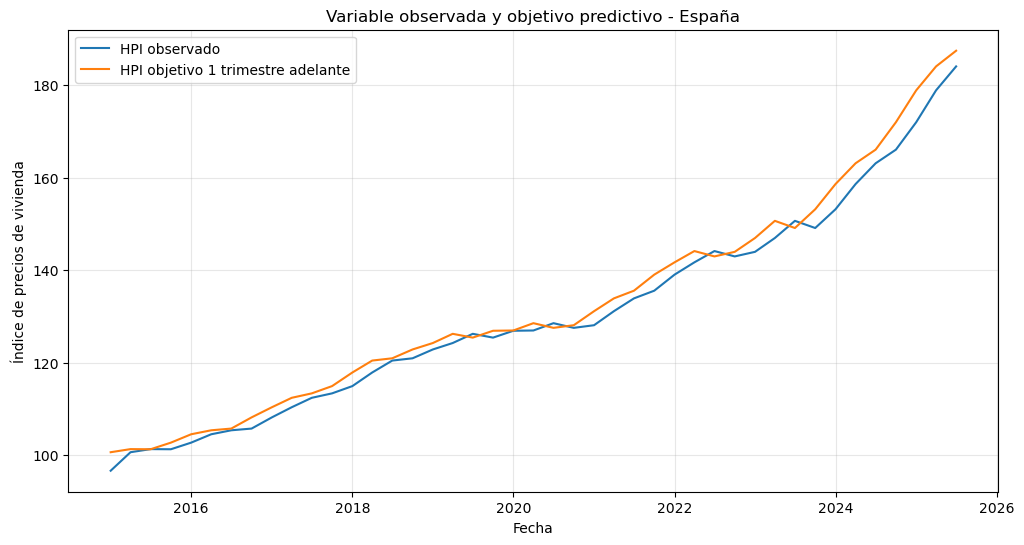

In [16]:
import matplotlib.pyplot as plt

spain = features_df[features_df["country"] == "España"]

plt.figure(figsize=(12, 6))

plt.plot(spain["date"], spain["hpi"], label="HPI observado")
plt.plot(spain["date"], spain["hpi_target_1q"], label="HPI objetivo 1 trimestre adelante")

plt.title("Variable observada y objetivo predictivo - España")
plt.xlabel("Fecha")
plt.ylabel("Índice de precios de vivienda")
plt.legend()
plt.grid(alpha=0.3)

plt.show()

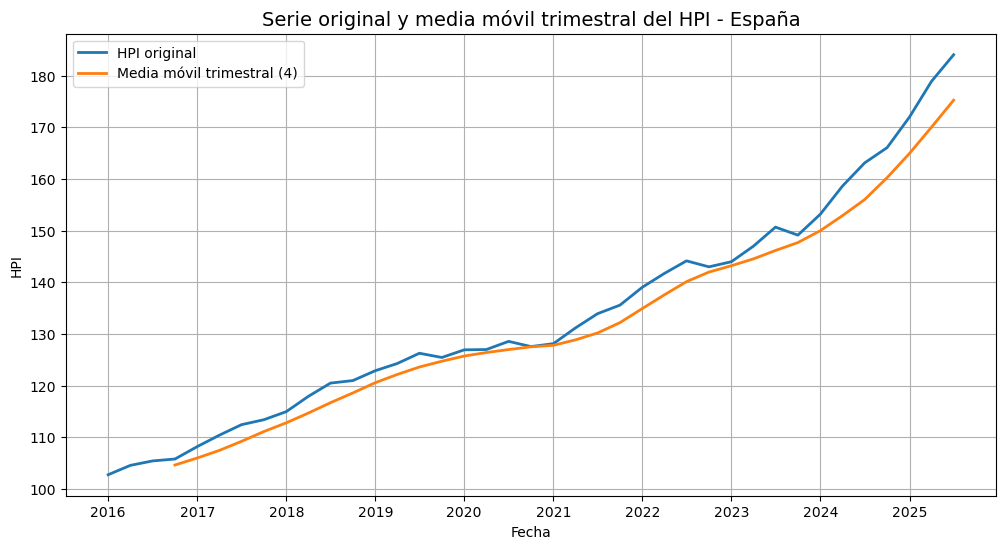

In [17]:
import pandas as pd
import matplotlib.pyplot as plt

# =========================
# CARGAR DATASET FINAL
# =========================

df = pd.read_csv(
    "../data/processed/housing_dataset_features.csv",
    parse_dates=["date"]
)

# =========================
# FILTRAR ESPAÑA
# =========================

spain = df[df["country"] == "España"].copy()

# =========================
# CREAR MEDIA MÓVIL
# =========================

spain["hpi_rolling_mean_4"] = (
    spain["hpi"]
    .rolling(window=4)
    .mean()
)

# =========================
# GRÁFICA
# =========================

plt.figure(figsize=(12,6))

plt.plot(
    spain["date"],
    spain["hpi"],
    label="HPI original",
    linewidth=2
)

plt.plot(
    spain["date"],
    spain["hpi_rolling_mean_4"],
    label="Media móvil trimestral (4)",
    linewidth=2
)

plt.title(
    "Serie original y media móvil trimestral del HPI - España",
    fontsize=14
)

plt.xlabel("Fecha")
plt.ylabel("HPI")

plt.legend()

plt.grid(True)

# =========================
# GUARDAR FIGURA
# =========================

plt.savefig(
    "../results/figures/hpi_rolling_mean_spain.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()